# 2023년 요일별 합산값 비교 (0~1 scaled)

- 교통량: `서강대교`, `마포대교`, `원효대교`의 일별 총합을 다시 요일별로 모두 합산
- Target: `Data/Target_2023_raw.csv`를 `Data/한강공원 주차장 일별 이용 현황.csv` 날짜 기준으로 복원 후 요일별 모두 합산
- 비교 방식: 교통량 합산 시리즈와 target 합산 시리즈를 각각 `0~1 min-max scaling`


In [1]:
import os
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/codex-mplconfig-team_pl")

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import font_manager

cwd = Path.cwd().resolve()
candidates = [cwd, cwd.parent]
PROJECT_ROOT = next(
    (path for path in candidates if (path / "Data").exists() and (path / "Note").exists()),
    cwd,
)

TRAFFIC_PATH = PROJECT_ROOT / "Data/Trafficdata/traffic_23.csv"
TARGET_PATH = PROJECT_ROOT / "Data/Target_2023_raw.csv"
PARKING_RAW_PATH = PROJECT_ROOT / "Data/한강공원 주차장 일별 이용 현황.csv"

OUTPUT_PLOT_PATH = PROJECT_ROOT / "Data/outputs/traffic_target_weekday_aggregate_scaled_2023.png"
OUTPUT_SUMMARY_PATH = PROJECT_ROOT / "Data/outputs/traffic_target_weekday_aggregate_scaled_2023.csv"
OUTPUT_DAILY_PATH = PROJECT_ROOT / "Data/outputs/traffic_target_weekday_daily_overlap_2023.csv"

SELECTED_BRIDGES = ["서강대교", "마포대교", "원효대교"]
WEEKDAY_ORDER = [
    (0, "월요일"),
    (1, "화요일"),
    (2, "수요일"),
    (3, "목요일"),
    (4, "금요일"),
    (5, "토요일"),
    (6, "일요일"),
]


In [2]:
def configure_matplotlib() -> None:
    font_candidates = ["AppleGothic", "Malgun Gothic", "NanumGothic", "DejaVu Sans"]
    available_fonts = {font.name for font in font_manager.fontManager.ttflist}
    for font_name in font_candidates:
        if font_name in available_fonts:
            plt.rcParams["font.family"] = font_name
            break
    plt.rcParams["axes.unicode_minus"] = False


def scale_to_zero_one(series: pd.Series) -> pd.Series:
    min_value = series.min()
    max_value = series.max()
    if pd.isna(min_value) or pd.isna(max_value) or min_value == max_value:
        return pd.Series(0.0, index=series.index, dtype=float)
    return (series - min_value) / (max_value - min_value)


def load_traffic_daily() -> pd.DataFrame:
    traffic_df = pd.read_csv(TRAFFIC_PATH)
    traffic_df["일자"] = pd.to_datetime(traffic_df["일자"].astype(str), format="%Y%m%d")

    hour_cols = sorted(
        [column for column in traffic_df.columns if column.endswith("시") and column[:-1].isdigit()],
        key=lambda column: int(column[:-1]),
    )

    filtered_df = traffic_df[traffic_df["지점명"].isin(SELECTED_BRIDGES)].copy()
    filtered_df["traffic_total"] = filtered_df[hour_cols].sum(axis=1)

    return (
        filtered_df.groupby("일자", as_index=False)["traffic_total"]
        .sum()
        .sort_values("일자")
        .reset_index(drop=True)
    )


def restore_target_rows_with_dates() -> pd.DataFrame:
    target_raw_df = pd.read_csv(TARGET_PATH).reset_index(drop=True)

    parking_raw_df = pd.read_csv(PARKING_RAW_PATH, encoding="cp949")
    parking_raw_df["날짜"] = pd.to_datetime(parking_raw_df["날짜"])

    source_df = parking_raw_df[
        (parking_raw_df["지구별"] == "PLT-008")
        & (parking_raw_df["날짜"].dt.year == 2023)
    ].copy()

    source_compare_df = (
        source_df.assign(year=source_df["날짜"].dt.year)[["주차장명", "주차대수", "year"]]
        .reset_index(drop=True)
        .copy()
    )

    comparable_source_df = source_compare_df.copy()
    comparable_target_df = target_raw_df.copy()
    comparable_source_df["주차장명"] = comparable_source_df["주차장명"].astype(str)
    comparable_target_df["주차장명"] = comparable_target_df["주차장명"].astype(str)

    for column in ["주차대수", "year"]:
        comparable_source_df[column] = pd.to_numeric(comparable_source_df[column], errors="raise")
        comparable_target_df[column] = pd.to_numeric(comparable_target_df[column], errors="raise")

    mismatch_mask = comparable_source_df.ne(comparable_target_df).any(axis=1)
    if mismatch_mask.any():
        mismatch_count = int(mismatch_mask.sum())
        raise ValueError(f"Target_2023_raw.csv mismatch rows: {mismatch_count}")

    return pd.concat(
        [
            source_df[["날짜"]].reset_index(drop=True),
            target_raw_df,
        ],
        axis=1,
    )


def load_target_daily() -> tuple[pd.DataFrame, list[str]]:
    restored_target_df = restore_target_rows_with_dates()
    target_daily_df = (
        restored_target_df.groupby("날짜", as_index=False)["주차대수"]
        .sum()
        .rename(columns={"날짜": "일자", "주차대수": "target_total"})
        .sort_values("일자")
        .reset_index(drop=True)
    )

    full_dates = pd.DataFrame({"일자": pd.date_range("2023-01-01", "2023-12-31", freq="D")})
    missing_dates = full_dates.merge(target_daily_df, on="일자", how="left")
    missing_dates = missing_dates[missing_dates["target_total"].isna()]["일자"].dt.strftime("%Y-%m-%d").tolist()
    return target_daily_df, missing_dates


def build_merged_daily() -> tuple[pd.DataFrame, list[str]]:
    traffic_daily_df = load_traffic_daily()
    target_daily_df, missing_target_dates = load_target_daily()

    merged_daily_df = (
        traffic_daily_df.merge(target_daily_df, on="일자", how="inner")
        .sort_values("일자")
        .reset_index(drop=True)
    )
    merged_daily_df["weekday_num"] = merged_daily_df["일자"].dt.dayofweek
    merged_daily_df["요일"] = merged_daily_df["weekday_num"].map(dict(WEEKDAY_ORDER))
    return merged_daily_df, missing_target_dates


def build_weekday_aggregate_df(merged_daily_df: pd.DataFrame) -> pd.DataFrame:
    weekday_aggregate_df = (
        merged_daily_df.groupby(["weekday_num", "요일"], as_index=False)
        .agg(
            traffic_total_sum=("traffic_total", "sum"),
            target_total_sum=("target_total", "sum"),
            표본일수=("일자", "size"),
        )
        .sort_values("weekday_num")
        .reset_index(drop=True)
    )
    weekday_aggregate_df["traffic_scaled_0_1"] = scale_to_zero_one(weekday_aggregate_df["traffic_total_sum"])
    weekday_aggregate_df["target_scaled_0_1"] = scale_to_zero_one(weekday_aggregate_df["target_total_sum"])
    return weekday_aggregate_df


def plot_weekday_aggregate_scaled(weekday_aggregate_df: pd.DataFrame, missing_target_dates: list[str]) -> None:
    configure_matplotlib()

    fig, ax = plt.subplots(figsize=(12, 6))
    x_positions = list(range(len(weekday_aggregate_df)))

    traffic_color = "#1f77b4"
    target_color = "#ff7f0e"

    ax.plot(
        x_positions,
        weekday_aggregate_df["traffic_scaled_0_1"],
        color=traffic_color,
        linewidth=2.6,
        marker="o",
        markersize=7,
        label="교통량 합산값 (0~1 scaled)",
    )
    ax.plot(
        x_positions,
        weekday_aggregate_df["target_scaled_0_1"],
        color=target_color,
        linewidth=2.6,
        marker="o",
        markersize=7,
        label="Target 합산값 (0~1 scaled)",
    )

    for idx, row in weekday_aggregate_df.iterrows():
        ax.text(idx, row["traffic_scaled_0_1"] + 0.04, f"{row['traffic_scaled_0_1']:.2f}", color=traffic_color, fontsize=10, ha="center")
        ax.text(idx, row["target_scaled_0_1"] - 0.06, f"{row['target_scaled_0_1']:.2f}", color=target_color, fontsize=10, ha="center")

    ax.set_xticks(x_positions)
    ax.set_xticklabels(weekday_aggregate_df["요일"])
    ax.set_ylim(-0.1, 1.1)
    ax.set_ylabel("0~1 scaled value")
    ax.set_xlabel("요일")
    ax.set_title("2023년 요일별 합산값 비교 (교통량 vs Target, 0~1 scaled)")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(frameon=False, loc="upper left")

    note_lines = [
        "원자료 합산 기준",
        "교통량: 서강대교·마포대교·원효대교",
        "Target: 여의도 주차장(PLT-008)",
    ]
    if missing_target_dates:
        note_lines.append(f"Target 결측: {', '.join(missing_target_dates)}")

    ax.text(1.02, 0.98, "\n".join(note_lines), transform=ax.transAxes, ha="left", va="top", fontsize=10)
    plt.tight_layout()
    plt.show()


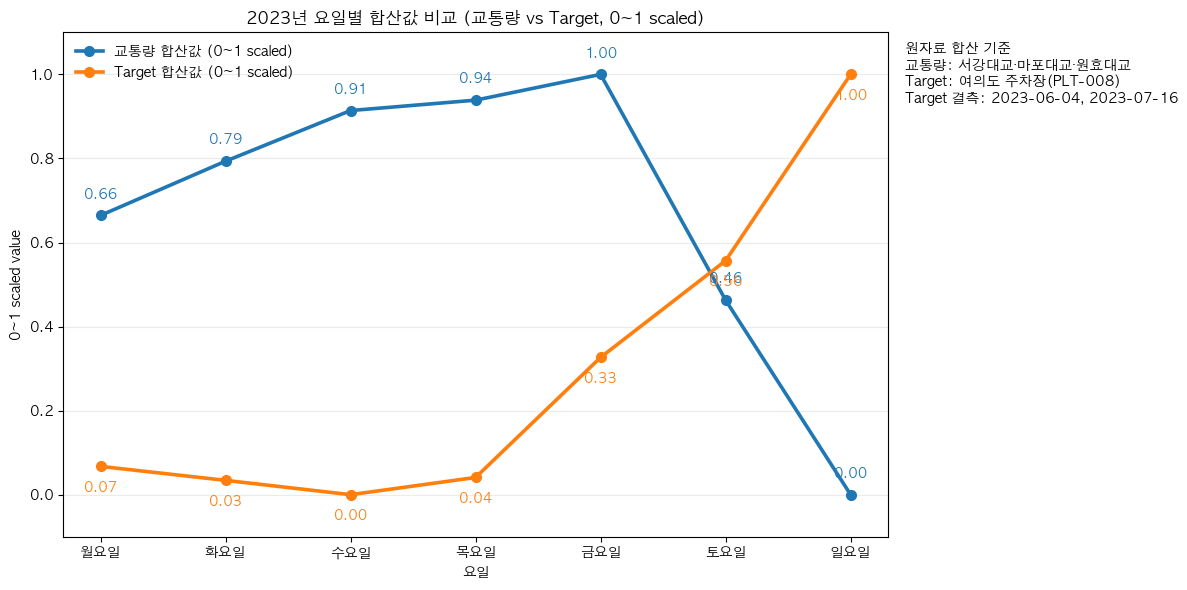

Saved plot: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/outputs/traffic_target_weekday_aggregate_scaled_2023.png
Saved summary table: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/outputs/traffic_target_weekday_aggregate_scaled_2023.csv
Saved overlap daily data: /Users/restitutor/Documents/Restitutor/Workspace/Flutter-Python/Python/Team_PL/outputs/traffic_target_weekday_daily_overlap_2023.csv


,weekday_num,요일,traffic_total_sum,target_total_sum,표본일수,traffic_scaled_0_1,target_scaled_0_1
0,0,월요일,9943207.0,238727,52,0.664445,0.067327
1,1,화요일,10399999.0,235311,52,0.793437,0.034101
2,2,수요일,10826760.0,231805,52,0.913948,0.000000
3,3,목요일,10914252.0,236019,52,0.938655,0.040988
4,4,금요일,11131491.0,265393,52,1.000000,0.326697
5,5,토요일,9229127.0,289050,52,0.462799,0.556798
6,6,일요일,7590239.0,334616,51,0.000000,1.000000


In [3]:
merged_daily_df, missing_target_dates = build_merged_daily()
weekday_aggregate_df = build_weekday_aggregate_df(merged_daily_df)

merged_daily_df.to_csv(OUTPUT_DAILY_PATH, index=False, encoding="utf-8-sig")
weekday_aggregate_df.to_csv(OUTPUT_SUMMARY_PATH, index=False, encoding="utf-8-sig")

plot_weekday_aggregate_scaled(weekday_aggregate_df, missing_target_dates)

print(f"Saved plot: {OUTPUT_PLOT_PATH}")
print(f"Saved summary table: {OUTPUT_SUMMARY_PATH}")
print(f"Saved overlap daily data: {OUTPUT_DAILY_PATH}")
weekday_aggregate_df
